 Phase 2 – Data Preparation

 Objective

Prepare reusable working copies of the datasets for analysis while preserving the raw datasets unchanged.

Import Libraries

In [1]:
import pandas as pd
import numpy as np
import re
from pathlib import Path

Configure Project Paths

In [2]:
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent

RAW_DATA = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA = PROJECT_ROOT / "data" / "processed"
OUTPUT_DATA = PROJECT_ROOT / "data" / "outputs"

PROCESSED_DATA.mkdir(parents=True, exist_ok=True)
OUTPUT_DATA.mkdir(parents=True, exist_ok=True)

print("Notebook:", NOTEBOOK_DIR)
print("Project:", PROJECT_ROOT)
print("Raw Exists:", RAW_DATA.exists())

Notebook: d:\sivahitesh\Desktop\Tail_project\Notebooks
Project: d:\sivahitesh\Desktop\Tail_project
Raw Exists: True


Load the Datasets

In [3]:
retail_panel = pd.read_csv(RAW_DATA / "retail_panel.csv")
competitor = pd.read_csv(RAW_DATA / "competitor_activity.csv")
kestrel = pd.read_csv(RAW_DATA / "kestrel_sales.csv")

print("CSV files loaded successfully.")

CSV files loaded successfully.


Load JSON Lines

In [4]:
audience = pd.read_json(
    RAW_DATA / "audience_signal.jsonl",
    lines=True
)

print("JSONL loaded successfully.")

JSONL loaded successfully.


Check Excel Sheets

In [5]:
excel = pd.ExcelFile(RAW_DATA / "market_master.xlsx")
print(excel.sheet_names)

['District_Master', 'Panel_Coverage', 'Distribution_Audit']


Load Excel Sheets

In [6]:
district_master = pd.read_excel(
    RAW_DATA / "market_master.xlsx",
    sheet_name="District_Master",
    header=4
)

panel_coverage = pd.read_excel(
    RAW_DATA / "market_master.xlsx",
    sheet_name="Panel_Coverage"
)

distribution = pd.read_excel(
    RAW_DATA / "market_master.xlsx",
    sheet_name="Distribution_Audit"
)

print("Excel sheets loaded successfully.")

Excel sheets loaded successfully.


Verify Everything Loaded

In [7]:
datasets = {
    "Retail Panel": retail_panel,
    "Competitor": competitor,
    "Kestrel": kestrel,
    "Audience": audience,
    "District Master": district_master,
    "Panel Coverage": panel_coverage,
    "Distribution": distribution
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

Retail Panel: (1428039, 21)
Competitor: (41616, 12)
Kestrel: (49939, 13)
Audience: (393815, 19)
District Master: (340, 9)
Panel Coverage: (8160, 8)
Distribution: (8160, 9)


Create Working Copies

In [8]:
# Create working copies of every dataset

retail_panel_clean = retail_panel.copy()
competitor_clean = competitor.copy()
kestrel_clean = kestrel.copy()
audience_clean = audience.copy()

district_master_clean = district_master.copy()
panel_coverage_clean = panel_coverage.copy()
distribution_clean = distribution.copy()

print("Working copies created successfully.")

Working copies created successfully.


Verify the Copies

In [9]:
verification = pd.DataFrame({
    "Dataset": [
        "Retail Panel",
        "Competitor",
        "Kestrel",
        "Audience",
        "District Master",
        "Panel Coverage",
        "Distribution"
    ],
    "Raw Rows": [
        len(retail_panel),
        len(competitor),
        len(kestrel),
        len(audience),
        len(district_master),
        len(panel_coverage),
        len(distribution)
    ],
    "Working Rows": [
        len(retail_panel_clean),
        len(competitor_clean),
        len(kestrel_clean),
        len(audience_clean),
        len(district_master_clean),
        len(panel_coverage_clean),
        len(distribution_clean)
    ]
})

verification

,Dataset,Raw Rows,Working Rows
0,Retail Panel,1428039,1428039
1,Competitor,41616,41616
2,Kestrel,49939,49939
3,Audience,393815,393815
4,District Master,340,340
5,Panel Coverage,8160,8160
6,Distribution,8160,8160


Create a Reusable Data Quality Function

In [10]:
def profile_dataset(df, name):
    """Generate a basic data quality summary."""

    return pd.DataFrame({
        "Dataset": [name],
        "Rows": [len(df)],
        "Columns": [df.shape[1]],
        "Duplicate Rows": [df.duplicated().sum()],
        "Missing Cells": [df.isna().sum().sum()],
        "Missing %": [
            round(
                df.isna().sum().sum() /
                (df.shape[0] * df.shape[1]) * 100,
                2
            )
        ]
    })

Generate Quality Summary

In [11]:
quality_summary = pd.concat([
    profile_dataset(retail_panel_clean, "Retail Panel"),
    profile_dataset(competitor_clean, "Competitor"),
    profile_dataset(kestrel_clean, "Kestrel"),
    profile_dataset(audience_clean, "Audience"),
    profile_dataset(district_master_clean, "District Master"),
    profile_dataset(panel_coverage_clean, "Panel Coverage"),
    profile_dataset(distribution_clean, "Distribution")
], ignore_index=True)

quality_summary

,Dataset,Rows,Columns,Duplicate Rows,Missing Cells,Missing %
0,Retail Panel,1428039,21,27746,1607880,5.36
1,Competitor,41616,12,816,27939,5.59
2,Kestrel,49939,13,979,0,0.00
3,Audience,393815,19,7645,59816,0.80
4,District Master,340,9,0,333,10.88
5,Panel Coverage,8160,8,0,0,0.00
6,Distribution,8160,9,0,0,0.00


Save the Quality Report

In [12]:
quality_summary.to_csv(
    OUTPUT_DATA / "quality_report.csv",
    index=False
)

print("Quality report saved successfully.")

Quality report saved successfully.


Find Missing Values by Column

In [13]:
def missing_by_column(df, name):

    missing = (
        df.isna()
          .sum()
          .reset_index()
    )

    missing.columns = ["Column", "Missing Count"]

    missing["Missing %"] = (
        missing["Missing Count"] / len(df) * 100
    ).round(2)

    missing["Dataset"] = name

    return missing.sort_values(
        "Missing %",
        ascending=False
    )

Check Retail Panel Missing Values

In [14]:
retail_missing = missing_by_column(
    retail_panel_clean,
    "Retail Panel"
)

retail_missing.head(10)

,Column,Missing Count,Missing %,Dataset
19,store_audit_notes,1307683,91.57,Retail Panel
15,unit_price_inr,164464,11.52,Retail Panel
17,discount_pct,107052,7.50,Retail Panel
18,projection_weight,28681,2.01,Retail Panel
0,audit_timestamp,0,0.00,Retail Panel
4,district_id,0,0.00,Retail Panel
3,numeric_outlet_id,0,0.00,Retail Panel
2,outlet_id,0,0.00,Retail Panel
1,month_id,0,0.00,Retail Panel
5,district_name,0,0.00,Retail Panel


Duplicate Analysis

In [15]:
duplicate_summary = pd.DataFrame({
    "Dataset": [
        "Retail Panel",
        "Competitor",
        "Kestrel",
        "Audience"
    ],
    "Duplicate Rows": [
        retail_panel_clean.duplicated().sum(),
        competitor_clean.duplicated().sum(),
        kestrel_clean.duplicated().sum(),
        audience_clean.duplicated().sum()
    ]
})

duplicate_summary

,Dataset,Duplicate Rows
0,Retail Panel,27746
1,Competitor,816
2,Kestrel,979
3,Audience,7645


Visualize Duplicate Rows

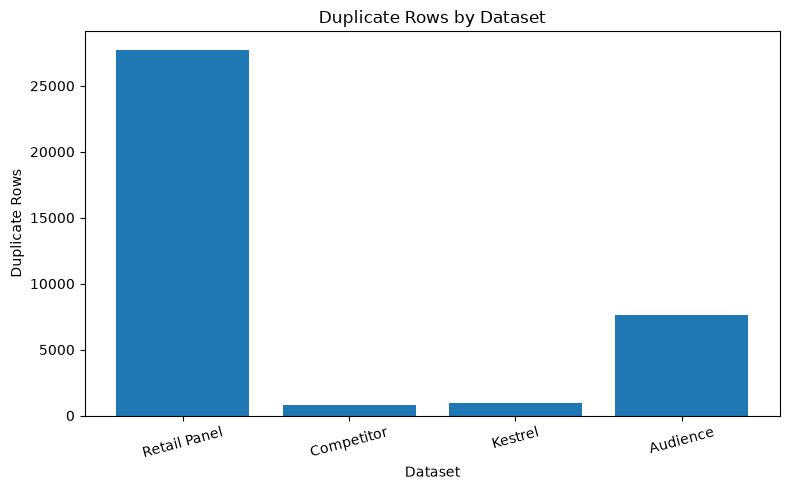

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    duplicate_summary["Dataset"],
    duplicate_summary["Duplicate Rows"]
)

plt.title("Duplicate Rows by Dataset")
plt.xlabel("Dataset")
plt.ylabel("Duplicate Rows")

plt.xticks(rotation=15)

plt.tight_layout()

plt.show()

Explanation:
A bar chart showing which dataset contains the most duplicate records.

Standardize Timestamps

Create a Universal Date Parser

In [17]:
from datetime import datetime

def parse_mixed_datetime(value):
    """Convert multiple timestamp formats into pandas datetime."""

    if pd.isna(value):
        return pd.NaT

    value = str(value).strip()

    # Handle epoch milliseconds
    if value.isdigit() and len(value) >= 12:
        try:
            return pd.to_datetime(int(value), unit="ms")
        except:
            pass

    formats = [
        "%d-%m-%Y",
        "%Y/%m/%d",
        "%m-%d-%y",
        "%Y-%m-%d",
        "%d/%m/%Y"
    ]

    for fmt in formats:
        try:
            return pd.to_datetime(datetime.strptime(value, fmt))
        except:
            continue

    try:
        return pd.to_datetime(value)
    except:
        return pd.NaT

Detect Date Columns Automatically

In [18]:
def detect_date_columns(df):
    """Find columns that likely contain dates."""

    date_cols = []

    for col in df.columns:
        if any(keyword in col.lower() for keyword in ["date", "time", "month"]):
            date_cols.append(col)

    return date_cols

Apply Timestamp Standardization

In [24]:
datasets = {
    "Retail": retail_panel_clean,
    "Competitor": competitor_clean,
    "Kestrel": kestrel_clean,
    "Audience": audience_clean,
    "Distribution": distribution_clean
}

for name, df in datasets.items():
    date_cols = detect_date_columns(df)

    for col in date_cols:
        # Use Pandas' fast vectorized parser
        df[col] = pd.to_datetime(df[col], errors="coerce", format="mixed")

    print(f"{name}: {len(date_cols)} date columns standardized.")

print("Timestamp standardization completed.")

Retail: 2 date columns standardized.
Competitor: 2 date columns standardized.
Kestrel: 2 date columns standardized.
Audience: 3 date columns standardized.
Distribution: 0 date columns standardized.
Timestamp standardization completed.


Standardize District Names

Create a District Standardization Function

In [27]:
district_mapping = {
    "bangalore": "bengaluru",
    "bangalore urban": "bengaluru",
    "bengaluru": "bengaluru",
    "bengaluru urban": "bengaluru"
}

def standardize_district(value):

    if pd.isna(value):
        return value

    value = str(value).strip().lower()
    value = re.sub(r"\s+", " ", value)

    return district_mapping.get(value, value)

Apply District Standardization

In [29]:
# Apply district standardization to all datasets

for df in [
    retail_panel_clean,
    competitor_clean,
    kestrel_clean,
    audience_clean,
    district_master_clean,
    panel_coverage_clean,
    distribution_clean
]:
    district_cols = [
        col for col in df.columns
        if "district" in col.lower()
    ]

    for col in district_cols:
        df[col] = df[col].apply(standardize_district)

print("District names standardized.")

District names standardized.


Validate Join Keys

Before combining datasets, we should identify districts that don't match between tables.

Compare District Lists

In [31]:
print("District Master Columns:")
print(district_master_clean.columns.tolist())

print("\nPanel Coverage Columns:")
print(panel_coverage_clean.columns.tolist())

District Master Columns:
['District_Code', 'District_Name', 'State_Union_Territory', 'Total_Population', 'Urban_Population_Share_Pct', 'Rural_Population_Share_Pct', 'Median_Income_Band', 'Estimated_Total_Retail_Universe', 'Census_Demographic_Notes']

Panel Coverage Columns:
['District_Ref_ID', 'Month', 'District_Name', 'State', 'Sampled_Outlets', 'Estimated_Total_Outlets', 'Panel_Coverage_Pct', 'Audit_Reliability_Tier']


In [32]:
# Automatically find the district column
def find_district_column(df):
    for col in df.columns:
        if "district" in col.lower():
            return col
    return None

master_col = find_district_column(district_master_clean)
coverage_col = find_district_column(panel_coverage_clean)

print("Master column:", master_col)
print("Coverage column:", coverage_col)

master_districts = set(
    district_master_clean[master_col].dropna().astype(str).str.lower()
)

coverage_districts = set(
    panel_coverage_clean[coverage_col].dropna().astype(str).str.lower()
)

missing_in_master = coverage_districts - master_districts

print("Districts missing from master:", len(missing_in_master))

Master column: District_Code
Coverage column: District_Ref_ID
Districts missing from master: 680


Save Unmatched Districts

In [33]:
pd.DataFrame({
    "Unmatched Districts": sorted(missing_in_master)
}).to_csv(
    OUTPUT_DATA / "unmatched_districts.csv",
    index=False
)

print("Unmatched district report saved.")

Unmatched district report saved.


Save Processed Datasets

In [34]:
processed_files = {
    "retail_panel_processed.csv": retail_panel_clean,
    "competitor_processed.csv": competitor_clean,
    "kestrel_processed.csv": kestrel_clean,
    "audience_processed.csv": audience_clean,
    "district_master_processed.csv": district_master_clean,
    "panel_coverage_processed.csv": panel_coverage_clean,
    "distribution_processed.csv": distribution_clean
}

for filename, df in processed_files.items():
    df.to_csv(PROCESSED_DATA / filename, index=False)

print("All processed datasets saved successfully.")

All processed datasets saved successfully.


Verify Exported Files

In [35]:
print("Processed Files:")
for file in sorted(PROCESSED_DATA.iterdir()):
    print("✓", file.name)

print("\nOutput Files:")
for file in sorted(OUTPUT_DATA.iterdir()):
    print("✓", file.name)

Processed Files:
✓ audience_processed.csv
✓ competitor_processed.csv
✓ distribution_processed.csv
✓ district_master_processed.csv
✓ kestrel_processed.csv
✓ panel_coverage_processed.csv
✓ retail_panel_processed.csv

Output Files:
✓ dataset_summary.csv
✓ quality_report.csv
✓ unmatched_districts.csv


Summary

By completing Phase 2, I have built a reusable preprocessing pipeline rather than simply cleaning a few files. The notebook now preserves the original data, documents data quality, standardizes important fields like dates and district names, validates joins between datasets, and produces processed datasets that become the foundation for the core business analysis in the next phase—calculating Demand Signal, Distribution Gap, Competitive Intensity, and ultimately the Whitespace Confidence Index (WCI) to identify the best districts for Kestrel's expansion.